# Feature Engineering for Sales Forecasting

## Introduction
This notebook focuses on transforming the cleaned dataset into meaningful features that can improve the performance of machine learning models. Feature engineering plays a critical role in time series forecasting by capturing temporal patterns, trends, and dependencies in the data.

## Objective
The objective of this notebook is to create lag features, rolling statistics, and time-based features that help the model understand past behavior and seasonal patterns in sales data.

-------------------------------------------------------------------------------------------------------------------------------------------------------

### Importing Required Libraries
The necessary libraries for data manipulation, visualization, and numerical computations are imported.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

### Loading Feature Engineered Dataset
The dataset generated from the EDA phase is loaded for further feature engineering.

In [2]:
df_daily = pd.read_csv(r"C:\Users\Aniket\Downloads\Capstone Projects\Sales Forecasting & Demand Prediction System\data\df_daily.csv")
df_daily["Date"] = pd.to_datetime(df_daily["Date"])
df_daily = df_daily.sort_values("Date")
df_daily.head()

,Date,Sales,rolling_mean,rolling_std,log_sales,year,month,dayofweek
0,2015-01-03,16.448,NaN,NaN,2.859225,2015,1,5
1,2015-01-04,288.060,NaN,NaN,5.666634,2015,1,6
2,2015-01-05,19.536,NaN,NaN,3.022179,2015,1,0
3,2015-01-06,4407.100,NaN,NaN,8.391199,2015,1,1
4,2015-01-07,87.158,NaN,NaN,4.479131,2015,1,2


### Dataset Overview
Basic structure, data types, and dimensions of the dataset are analyzed to understand the available features.

In [3]:
df_daily.shape

(1229, 8)

In [4]:
df_daily.info()

<class 'pandas.DataFrame'>
RangeIndex: 1229 entries, 0 to 1228
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          1229 non-null   datetime64[us]
 1   Sales         1229 non-null   float64       
 2   rolling_mean  1200 non-null   float64       
 3   rolling_std   1200 non-null   float64       
 4   log_sales     1229 non-null   float64       
 5   year          1229 non-null   int64         
 6   month         1229 non-null   int64         
 7   dayofweek     1229 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(3)
memory usage: 76.9 KB


### Creating Working Copy
A copy of the dataset is created to preserve the original data while performing feature transformations.

In [5]:
df_fe = df_daily.copy()

In [6]:
df_fe.drop(columns=["rolling_mean","rolling_std","log_sales"],inplace=True)

Rolling statistics created during EDA are removed here to avoid redundancy.
Fresh rolling features will be generated in this notebook using proper laggingto prevent data leakage and ensure that only past information is used.
Log-transformed sales where also removed as it was created for EDA purposes.The model will directly use original sales and engineered features.

### Lag Feature Creation

Lag features are created to capture past sales values. These features help the model learn temporal dependencies.
Common lags used:
- 1 day (recent trend)
- 7 days (weekly pattern)
- 14 days (bi-weekly pattern)
- 30 days (monthly pattern)

In [7]:
df_fe["lag_1"] = df_fe["Sales"].shift(1)
df_fe["lag_3"] = df_fe["Sales"].shift(3)
df_fe["lag_7"] = df_fe["Sales"].shift(7)
df_fe["lag_14"] = df_fe["Sales"].shift(14)
df_fe["lag_30"] = df_fe["Sales"].shift(30)

Lag features introduce historical dependencies into the dataset, allowing the model to understand how past sales influence future sales, which is essential for time series forecasting.

### Rolling Statistics Features
Rolling mean and standard deviation are calculated to smooth fluctuations and capture trends in the data. Rolling features are calculated using past values only (shifted by 1) to ensure no future data leakage into model training.

In [8]:
df_fe["rolling_mean_7"] = df_fe["Sales"].shift(1).rolling(7).mean()
df_fe["rolling_mean_14"] = df_fe["Sales"].shift(1).rolling(14).mean()
df_fe["rolling_mean_30"] = df_fe["Sales"].shift(1).rolling(30).mean()
df_fe["rolling_std_7"] = df_fe["Sales"].shift(1).rolling(7).std()

Rolling features help in reducing noise and capturing underlying trends in the data, making patterns more stable for the model to learn.

#### Feature Engineered Dataset Preview
The dataset is displayed after adding lag and rolling features to verify transformations.

In [9]:
df_fe

,Date,Sales,year,month,dayofweek,lag_1,lag_3,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_14,rolling_mean_30,rolling_std_7
0,2015-01-03,16.4480,2015,1,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-04,288.0600,2015,1,6,16.4480,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-05,19.5360,2015,1,0,288.0600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-01-06,4407.1000,2015,1,1,19.5360,16.448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2015-01-07,87.1580,2015,1,2,4407.1000,288.060,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,2018-12-26,814.5940,2018,12,2,2698.9270,1926.776,1895.926,2025.035,3666.157,3245.054286,2575.594571,3364.305033,2576.804034
1225,2018-12-27,177.6360,2018,12,3,814.5940,6233.054,377.736,580.936,5048.172,3090.578286,2489.134500,3269.252933,2700.600687
1226,2018-12-28,1657.3508,2018,12,4,177.6360,2698.927,2140.940,3897.714,1618.254,3061.992571,2460.327357,3106.901733,2734.942531
1227,2018-12-29,2915.5340,2018,12,5,1657.3508,814.594,7442.021,306.888,6912.944,2992.908400,2300.301414,3108.204960,2767.993744


#### Time-Based Feature Extraction
Additional time-based features are created to capture seasonality and calendar effects.

In [10]:
df_fe["day"] = df_fe["Date"].dt.day
df_fe["quarter"] = df_fe["Date"].dt.quarter
df_fe["is_weekend"] =df_fe["dayofweek"].isin([5,6]).astype(int)
df_fe["is_month_start"] = df_fe["Date"].dt.is_month_start.astype(int)
df_fe["is_month_end"] = df_fe["Date"].dt.is_month_end.astype(int)

Time-based features such as day, quarter,weekend and Month start and Month end indicators help the model capture seasonal patterns and behavioral trends in customer purchasing.

#### Handling Missing Values
Missing values are generated due to lag and rolling operations and must be handled before model training.

In [11]:
df_fe.isnull().sum()

Date                0
Sales               0
year                0
month               0
dayofweek           0
lag_1               1
lag_3               3
lag_7               7
lag_14             14
lag_30             30
rolling_mean_7      7
rolling_mean_14    14
rolling_mean_30    30
rolling_std_7       7
day                 0
quarter             0
is_weekend          0
is_month_start      0
is_month_end        0
dtype: int64

In [12]:
df_fe.dropna(inplace=True)
df_fe.isnull().sum()

Date               0
Sales              0
year               0
month              0
dayofweek          0
lag_1              0
lag_3              0
lag_7              0
lag_14             0
lag_30             0
rolling_mean_7     0
rolling_mean_14    0
rolling_mean_30    0
rolling_std_7      0
day                0
quarter            0
is_weekend         0
is_month_start     0
is_month_end       0
dtype: int64

Missing values are generated due to lag and rolling operations at the beginning of the dataset.
These rows are removed as they do not have sufficient historical data for feature creation.

In [13]:
df_fe.duplicated().sum()

np.int64(0)

There were no duuplicates in the data.

In [14]:
df_fe.shape

(1199, 19)

#### Final Dataset Shape
The final dataset structure is verified after feature engineering.Dataset size reduced due to removal of initial rows with missing lag/rolling values.
The remaining data is now fully suitable for model training.

#### Feature Correlation Analysis
A heatmap is used to analyze relationships between features and identify important predictors.

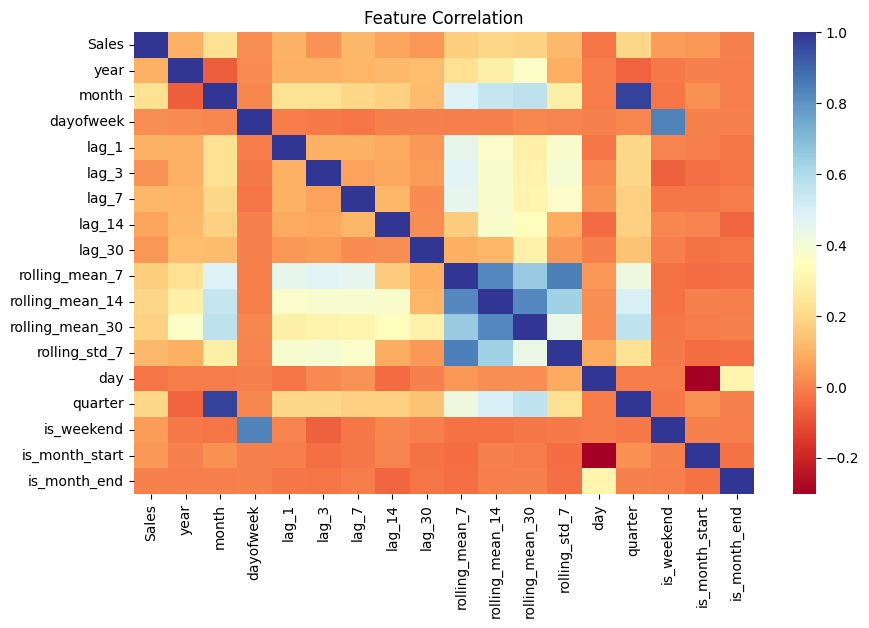

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(df_fe.select_dtypes(include=["number"]).corr(),cmap="RdYlBu")
plt.title("Feature Correlation")
plt.show()

Correlation heatmap helps identify relationships between engineered features.
Lag features typically show strong correlation with sales, indicating temporal dependency,
while rolling features capture smoothed trends in the data.

#### Saving Final Feature Engineered Dataset
The transformed dataset is saved for use in model building

In [16]:
df_fe.to_csv("df_feature_enigneered.csv",index=False)

Final feature-engineered dataset is saved for model training.
This ensures separation between preprocessing and modeling stages.

## Conclusion
Feature engineering significantly enhanced the dataset by introducing temporal dependencies, smoothing trends, and capturing seasonal patterns. These engineered features will improve the predictive performance of machine learning models in the next phase.